<a href="https://colab.research.google.com/github/Barrimanikanta/ShadowFox-/blob/main/Task_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

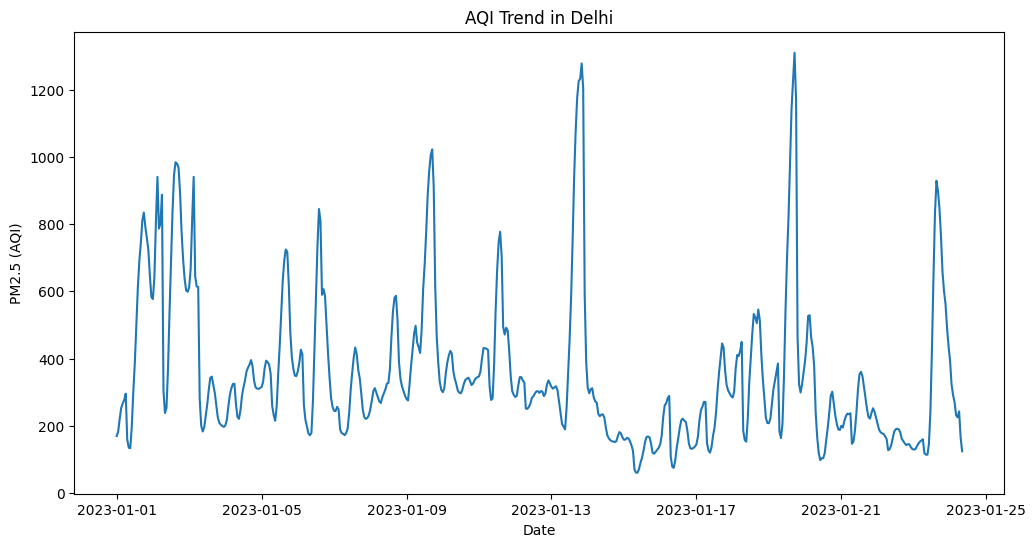

                               SARIMAX Results                                
Dep. Variable:                  pm2_5   No. Observations:                  561
Model:                 ARIMA(5, 1, 0)   Log Likelihood               -3144.267
Date:                Mon, 30 Mar 2026   AIC                           6300.534
Time:                        05:44:01   BIC                           6326.502
Sample:                             0   HQIC                          6310.674
                                - 561                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.4771      0.022     22.153      0.000       0.435       0.519
ar.L2         -0.0599      0.052     -1.152      0.249      -0.162       0.042
ar.L3          0.1317      0.026      5.044      0.0

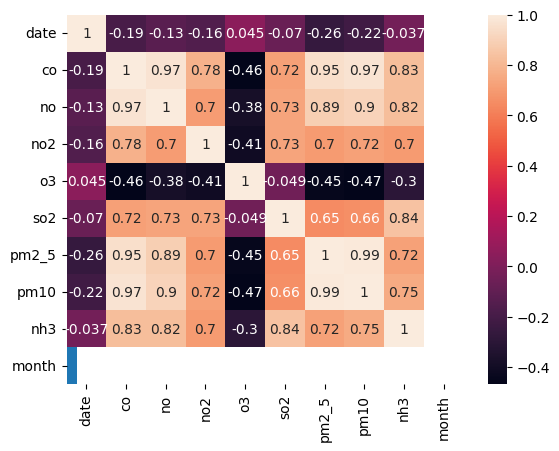

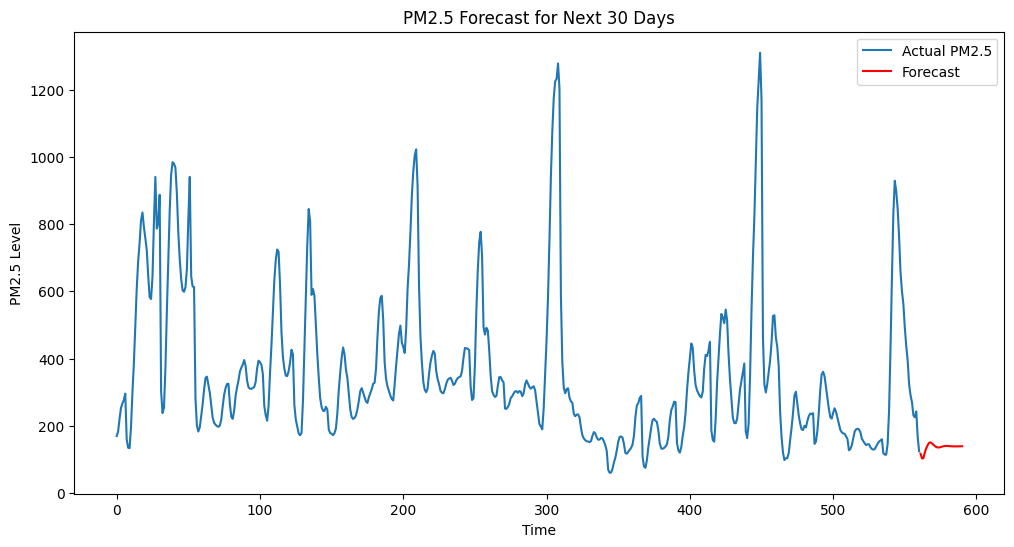

RMSE: 66.37533182791323


In [ ]:
import pandas as pd
data = pd.read_csv("/content/delhiaqi.csv")
data.head()
data.isnull().sum()
data = data.ffill()
data['date'] = pd.to_datetime(data['date'])
data.describe()
import matplotlib.pyplot as plt
plt.figure(figsize=(12,6))
plt.plot(data['date'], data['pm2_5'])
plt.title("AQI Trend in Delhi")
plt.xlabel("Date")
plt.ylabel("PM2.5 (AQI)")
plt.show()
data['month'] = data['date'].dt.month
monthly = data.groupby('month')['pm2_5'].mean()
monthly.plot(kind='bar')
plt.scatter(data['pm2_5'], data['pm10'])
plt.xlabel("PM2.5")
plt.ylabel("PM10")
import seaborn as sns
corr = data.corr()
sns.heatmap(corr, annot=True)
from sklearn.linear_model import LinearRegression
X = data[['pm2_5','pm10','no2']]
y = data['pm2_5']
model = LinearRegression()
model.fit(X,y)
model.score(X,y)
from statsmodels.tsa.arima.model import ARIMA
model = ARIMA(data['pm2_5'], order=(5,1,0))
model_fit = model.fit()
print(model_fit.summary())
forecast = model_fit.forecast(steps=30)

plt.figure(figsize=(12,6))
plt.plot(data['pm2_5'], label="Actual PM2.5")
plt.plot(range(len(data), len(data)+30), forecast, label="Forecast", color='red')

plt.title("PM2.5 Forecast for Next 30 Days")
plt.xlabel("Time")
plt.ylabel("PM2.5 Level")
plt.legend()
plt.show()
from sklearn.metrics import mean_squared_error
import numpy as np

pred = model_fit.predict(start=1, end=len(data)-1)

rmse = np.sqrt(mean_squared_error(data['pm2_5'][1:], pred))
print("RMSE:", rmse)